[nltk_data] Downloading package punkt to /Users/anniegrts/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
Device set to use mps:0


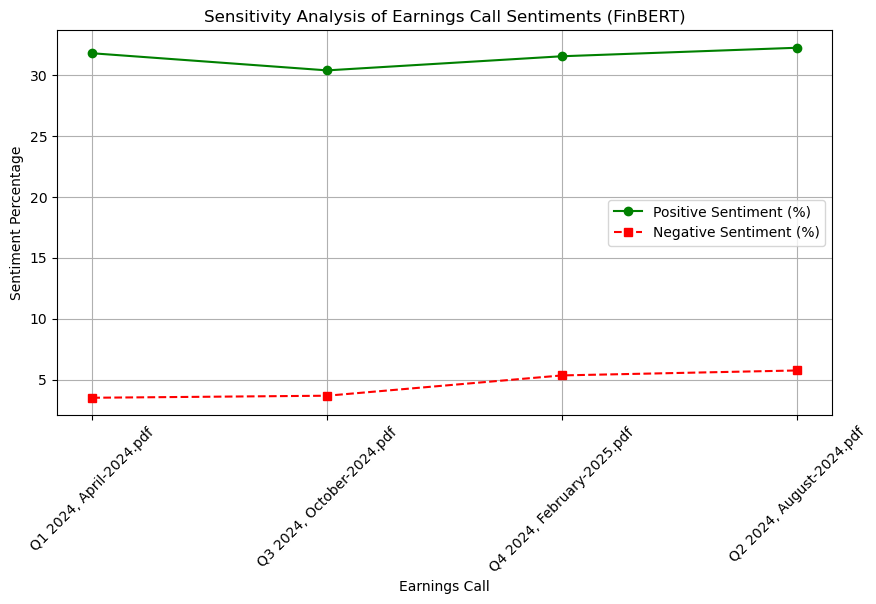

                Earnings Call  Positive  Neutral  Negative  Total Sentences  \
0     Q1 2024, April-2024.pdf       145      295        16              456   
1   Q3 2024, October-2024.pdf       124      269        15              408   
2  Q4 2024, February-2025.pdf       124      248        21              393   
3    Q2 2024, August-2024.pdf       129      248        23              400   

   Positive %  Negative %  
0   31.798246    3.508772  
1   30.392157    3.676471  
2   31.552163    5.343511  
3   32.250000    5.750000  


In [19]:
import os
import PyPDF2
import nltk
from nltk.tokenize import sent_tokenize
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, pipeline

# Download NLTK tokenizer (if not already installed)
nltk.download("punkt")

# Load FinBERT model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
sentiment_pipeline = pipeline("text-classification", model="ProsusAI/finbert")

# Folder containing earnings call PDFs
folder_path = "Earning calls transcripts"

# Function to extract text from a PDF file
def extract_text_from_pdf(pdf_path):
    text = ""
    with open(pdf_path, "rb") as pdf_file:
        reader = PyPDF2.PdfReader(pdf_file)
        for page in reader.pages:
            text += page.extract_text() + "\n"
    return text

# Function to process sentences safely (truncate if >512 tokens)
def analyze_text_with_truncation(text):
    tokenized_text = tokenizer.encode(text, truncation=True, max_length=512, return_tensors="pt")
    sentiment = sentiment_pipeline(text[:512])[0]  # Only send 512 chars to avoid token mismatch
    return sentiment

# Process each PDF in the folder
sentiment_results = []
for filename in os.listdir(folder_path):
    if filename.endswith(".pdf"):
        file_path = os.path.join(folder_path, filename)
        
        # Extract text from PDF
        transcript_text = extract_text_from_pdf(file_path)
        sentences = sent_tokenize(transcript_text)

        # Run sentiment analysis with truncation
        sentiments = [analyze_text_with_truncation(sentence) for sentence in sentences]

        # Count sentiment distribution
        sentiment_counts = {
            "positive": sum(1 for s in sentiments if s["label"] == "positive"),
            "neutral": sum(1 for s in sentiments if s["label"] == "neutral"),
            "negative": sum(1 for s in sentiments if s["label"] == "negative")
        }
        
        # Store results
        sentiment_results.append({
            "Earnings Call": filename,
            "Positive": sentiment_counts["positive"],
            "Neutral": sentiment_counts["neutral"],
            "Negative": sentiment_counts["negative"],
            "Total Sentences": len(sentiments),
            "Positive %": sentiment_counts["positive"] / len(sentiments) * 100,
            "Negative %": sentiment_counts["negative"] / len(sentiments) * 100
        })

# Convert results to DataFrame
df_results = pd.DataFrame(sentiment_results)

# 🎨 Plot sensitivity analysis (Positive vs. Negative %)
plt.figure(figsize=(10, 5))
plt.plot(df_results["Earnings Call"], df_results["Positive %"], marker="o", linestyle="-", label="Positive Sentiment (%)", color="green")
plt.plot(df_results["Earnings Call"], df_results["Negative %"], marker="s", linestyle="--", label="Negative Sentiment (%)", color="red")
plt.xlabel("Earnings Call")
plt.ylabel("Sentiment Percentage")
plt.title("Sensitivity Analysis of Earnings Call Sentiments (FinBERT)")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

# 📊 Print summarized sensitivity results
print(df_results)

[nltk_data] Downloading package punkt to /Users/anniegrts/nltk_data...
[nltk_data]   Package punkt is already up-to-date!



📄 Processing: Q1 2024, April-2024.pdf
📊 Section-level Sentiment:
  ➤ Prepared Remarks: Positive=4.05%, Negative=45.95%, Neutral=50.0%
  ➤ Q&A: Positive=1.92%, Negative=65.38%, Neutral=32.69%
  ➤ Conclusion: Positive=0.0%, Negative=100.0%, Neutral=0.0%
  ➤ Other: Positive=0.0%, Negative=100.0%, Neutral=0.0%

📄 Processing: Q3 2024, October-2024.pdf
📊 Section-level Sentiment:
  ➤ Prepared Remarks: Positive=4.34%, Negative=58.42%, Neutral=37.24%
  ➤ Q&A: Positive=0%, Negative=0%, Neutral=0%
  ➤ Conclusion: Positive=0.0%, Negative=100.0%, Neutral=0.0%
  ➤ Other: Positive=0.0%, Negative=100.0%, Neutral=0.0%

📄 Processing: Q4 2024, February-2025.pdf
📊 Section-level Sentiment:
  ➤ Prepared Remarks: Positive=5.59%, Negative=60.11%, Neutral=34.31%
  ➤ Q&A: Positive=0%, Negative=0%, Neutral=0%
  ➤ Conclusion: Positive=0.0%, Negative=100.0%, Neutral=0.0%
  ➤ Other: Positive=0.0%, Negative=100.0%, Neutral=0.0%

📄 Processing: Q2 2024, August-2024.pdf
📊 Section-level Sentiment:
  ➤ Prepared Remarks:

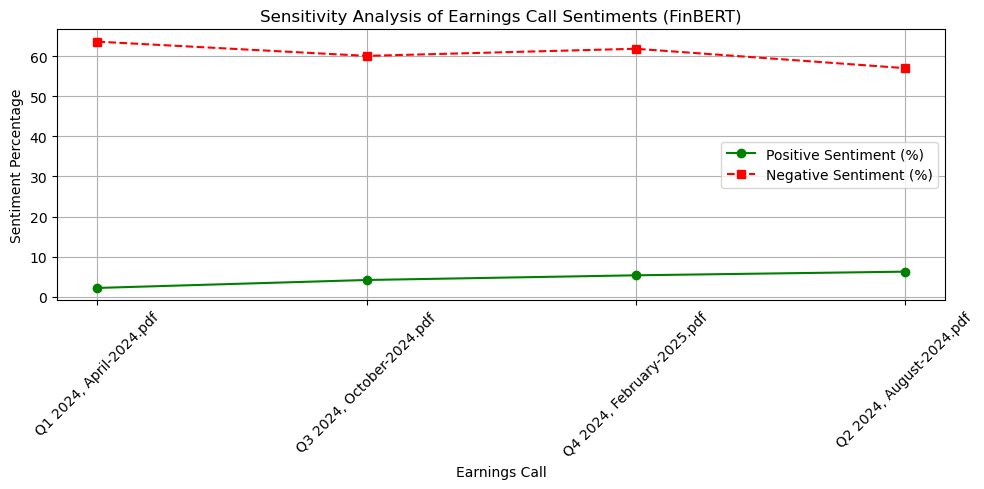

In [27]:
import os
import glob
import re
import torch
import pandas as pd
import matplotlib.pyplot as plt
from PyPDF2 import PdfReader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from nltk.tokenize import sent_tokenize
import nltk

# Setup
nltk.download('punkt')

# Load FinBERT model and tokenizer
finbert_model = AutoModelForSequenceClassification.from_pretrained("yiyanghkust/finbert-tone")
finbert_tokenizer = AutoTokenizer.from_pretrained("yiyanghkust/finbert-tone")
labels = ['negative', 'neutral', 'positive']

# Folder containing PDF earnings calls
FOLDER_PATH = "Earning calls transcripts"
pdf_files = glob.glob(os.path.join(FOLDER_PATH, "*.pdf"))

# Extract all text from PDF
def extract_text_from_pdf(pdf_path):
    try:
        reader = PdfReader(pdf_path)
        return " ".join([page.extract_text() or "" for page in reader.pages])
    except Exception as e:
        print(f"Error reading {pdf_path}: {e}")
        return ""

# Split transcript into sections
def split_into_sections(text):
    section_patterns = {
        'Prepared Remarks': r"(prepared remarks|opening remarks|introduction)",
        'Q&A': r"(q[\s&]*a|questions and answers|analyst questions)",
        'Conclusion': r"(conclusion|closing remarks|summary)"
    }

    sections = {'Prepared Remarks': '', 'Q&A': '', 'Conclusion': '', 'Other': ''}
    current_section = 'Other'
    for line in text.split('\n'):
        lower_line = line.lower().strip()
        matched = False
        for section, pattern in section_patterns.items():
            if re.search(pattern, lower_line):
                current_section = section
                matched = True
                break
        sections[current_section] += line + '\n'
    return sections

# Run FinBERT sentiment analysis on text
def analyze_sentiment_finbert(text):
    sentences = sent_tokenize(text)
    sentiments = {"positive": 0, "negative": 0, "neutral": 0}
    total = 0

    for sentence in sentences:
        if len(sentence.strip()) == 0:
            continue

        # Tokenize the sentence
        inputs = finbert_tokenizer(sentence, return_tensors="pt", truncation=True, max_length=512)

        # If the sentence is too long, split it into chunks of 512 tokens
        if inputs['input_ids'].size(1) > 512:
            chunks = [inputs['input_ids'][:, i:i+512] for i in range(0, inputs['input_ids'].size(1), 512)]
            attention_masks = [inputs['attention_mask'][:, i:i+512] for i in range(0, inputs['attention_mask'].size(1), 512)]
        else:
            chunks = [inputs['input_ids']]
            attention_masks = [inputs['attention_mask']]

        for chunk, attention_mask in zip(chunks, attention_masks):
            with torch.no_grad():
                outputs = finbert_model(input_ids=chunk, attention_mask=attention_mask)
            probs = torch.nn.functional.softmax(outputs.logits, dim=1)
            label = labels[probs.argmax()]
            sentiments[label] += 1
            total += 1

    if total == 0:
        return 0, 0, 0

    return round(sentiments["positive"] / total * 100, 2), round(sentiments["negative"] / total * 100, 2), round(sentiments["neutral"] / total * 100, 2)

# Main loop
overall_results = []

for pdf_file in pdf_files:
    file_name = os.path.basename(pdf_file)
    print(f"\n📄 Processing: {file_name}")
    text = extract_text_from_pdf(pdf_file)
    if not text.strip():
        print("No text found.")
        continue

    sections = split_into_sections(text)

    print("📊 Section-level Sentiment:")
    for sec_name, sec_text in sections.items():
        pos, neg, neu = analyze_sentiment_finbert(sec_text)
        print(f"  ➤ {sec_name}: Positive={pos}%, Negative={neg}%, Neutral={neu}%")

    # Overall sentiment from all sections combined
    full_text = "\n".join(sections.values())
    pos_pct, neg_pct, neu_pct = analyze_sentiment_finbert(full_text)

    overall_results.append({
        "Earnings Call": file_name,
        "Positive %": pos_pct,
        "Negative %": neg_pct,
        "Neutral %": neu_pct
    })

# Plot sentiment across earnings calls
if overall_results:
    df_results = pd.DataFrame(overall_results)
    plt.figure(figsize=(10, 5))
    plt.plot(df_results["Earnings Call"], df_results["Positive %"], marker="o", linestyle="-", label="Positive Sentiment (%)", color="green")
    plt.plot(df_results["Earnings Call"], df_results["Negative %"], marker="s", linestyle="--", label="Negative Sentiment (%)", color="red")
    plt.xlabel("Earnings Call")
    plt.ylabel("Sentiment Percentage")
    plt.title("Sensitivity Analysis of Earnings Call Sentiments (FinBERT)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

[nltk_data] Downloading package punkt to /Users/anniegrts/nltk_data...
[nltk_data]   Package punkt is already up-to-date!



📄 Processing: Q1 2024, April-2024.pdf
📊 Section-level Sentiment:
  ➤ Prepared Remarks: Positive=4.05%, Negative=45.95%, Neutral=50.0%
  ➤ Q&A: Positive=1.92%, Negative=65.38%, Neutral=32.69%
  ➤ Conclusion: Positive=0.0%, Negative=100.0%, Neutral=0.0%
  ➤ Other: Positive=0.0%, Negative=100.0%, Neutral=0.0%

📄 Processing: Q3 2024, October-2024.pdf
📊 Section-level Sentiment:
  ➤ Prepared Remarks: Positive=4.34%, Negative=58.42%, Neutral=37.24%
  ➤ Q&A: Positive=0%, Negative=0%, Neutral=0%
  ➤ Conclusion: Positive=0.0%, Negative=100.0%, Neutral=0.0%
  ➤ Other: Positive=0.0%, Negative=100.0%, Neutral=0.0%

📄 Processing: Q4 2024, February-2025.pdf
📊 Section-level Sentiment:
  ➤ Prepared Remarks: Positive=5.59%, Negative=60.11%, Neutral=34.31%
  ➤ Q&A: Positive=0%, Negative=0%, Neutral=0%
  ➤ Conclusion: Positive=0.0%, Negative=100.0%, Neutral=0.0%
  ➤ Other: Positive=0.0%, Negative=100.0%, Neutral=0.0%

📄 Processing: Q2 2024, August-2024.pdf
📊 Section-level Sentiment:
  ➤ Prepared Remarks:

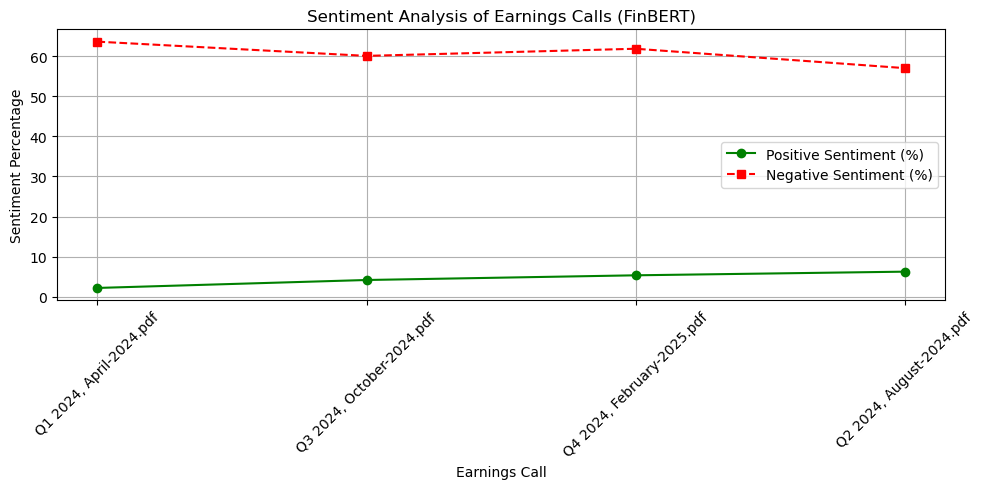

In [28]:
import os
import glob
import re
import torch
import pandas as pd
import matplotlib.pyplot as plt
from PyPDF2 import PdfReader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from nltk.tokenize import sent_tokenize
import nltk

# Setup
nltk.download('punkt')

# Load FinBERT model and tokenizer
finbert_model = AutoModelForSequenceClassification.from_pretrained("yiyanghkust/finbert-tone")
finbert_tokenizer = AutoTokenizer.from_pretrained("yiyanghkust/finbert-tone")
labels = ['negative', 'neutral', 'positive']

# Folder containing PDF earnings calls
FOLDER_PATH = "Earning calls transcripts"
pdf_files = glob.glob(os.path.join(FOLDER_PATH, "*.pdf"))

# Extract all text from PDF
def extract_text_from_pdf(pdf_path):
    try:
        reader = PdfReader(pdf_path)
        return " ".join([page.extract_text() or "" for page in reader.pages])
    except Exception as e:
        print(f"Error reading {pdf_path}: {e}")
        return ""

# Split transcript into sections
def split_into_sections(text):
    section_patterns = {
        'Prepared Remarks': r"(prepared remarks|opening remarks|introduction)",
        'Q&A': r"(q[\s&]*a|questions and answers|analyst questions)",
        'Conclusion': r"(conclusion|closing remarks|summary)"
    }

    sections = {'Prepared Remarks': '', 'Q&A': '', 'Conclusion': '', 'Other': ''}
    current_section = 'Other'
    for line in text.split('\n'):
        lower_line = line.lower().strip()
        matched = False
        for section, pattern in section_patterns.items():
            if re.search(pattern, lower_line):
                current_section = section
                matched = True
                break
        sections[current_section] += line + '\n'
    return sections

# Run FinBERT sentiment analysis on text
def analyze_sentiment_finbert(text):
    sentences = sent_tokenize(text)
    sentiments = {"positive": 0, "negative": 0, "neutral": 0}
    total = 0

    for sentence in sentences:
        if len(sentence.strip()) == 0:
            continue

        # Tokenize the sentence
        inputs = finbert_tokenizer(sentence, return_tensors="pt", truncation=True, max_length=512)

        # If the sentence is too long, split it into chunks of 512 tokens
        if inputs['input_ids'].size(1) > 512:
            chunks = [inputs['input_ids'][:, i:i+512] for i in range(0, inputs['input_ids'].size(1), 512)]
            attention_masks = [inputs['attention_mask'][:, i:i+512] for i in range(0, inputs['attention_mask'].size(1), 512)]
        else:
            chunks = [inputs['input_ids']]
            attention_masks = [inputs['attention_mask']]

        for chunk, attention_mask in zip(chunks, attention_masks):
            with torch.no_grad():
                outputs = finbert_model(input_ids=chunk, attention_mask=attention_mask)
            probs = torch.nn.functional.softmax(outputs.logits, dim=1)
            label = labels[probs.argmax()]
            sentiments[label] += 1
            total += 1

    if total == 0:
        return 0, 0, 0

    return round(sentiments["positive"] / total * 100, 2), round(sentiments["negative"] / total * 100, 2), round(sentiments["neutral"] / total * 100, 2)

# Main loop
overall_results = []

for pdf_file in pdf_files:
    file_name = os.path.basename(pdf_file)
    print(f"\n📄 Processing: {file_name}")
    text = extract_text_from_pdf(pdf_file)
    if not text.strip():
        print("No text found.")
        continue

    sections = split_into_sections(text)

    print("📊 Section-level Sentiment:")
    section_sentiments = {}
    for sec_name, sec_text in sections.items():
        pos, neg, neu = analyze_sentiment_finbert(sec_text)
        print(f"  ➤ {sec_name}: Positive={pos}%, Negative={neg}%, Neutral={neu}%")
        section_sentiments[sec_name] = {'Positive': pos, 'Negative': neg, 'Neutral': neu}

    # Overall sentiment from all sections combined
    full_text = "\n".join(sections.values())
    pos_pct, neg_pct, neu_pct = analyze_sentiment_finbert(full_text)

    overall_results.append({
        "Earnings Call": file_name,
        "Section Sentiments": section_sentiments,
        "Overall Positive %": pos_pct,
        "Overall Negative %": neg_pct,
        "Overall Neutral %": neu_pct
    })

# Plot sentiment across earnings calls
if overall_results:
    df_results = pd.DataFrame(overall_results)
    plt.figure(figsize=(10, 5))
    plt.plot(df_results["Earnings Call"], df_results["Overall Positive %"], marker="o", linestyle="-", label="Positive Sentiment (%)", color="green")
    plt.plot(df_results["Earnings Call"], df_results["Overall Negative %"], marker="s", linestyle="--", label="Negative Sentiment (%)", color="red")
    plt.xlabel("Earnings Call")
    plt.ylabel("Sentiment Percentage")
    plt.title("Sentiment Analysis of Earnings Calls (FinBERT)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()